# Klasyfikacja obrazów ultrasonograficznych BUSI
## Porównanie: ResNet50 vs DenseNet121 vs EfficientNetB7
Dataset: `Dataset_BUSI_noisy` (oryginalne obrazy + wersje z szumem Gaussowskim)  
Klasy: `benign`, `malignant`, `normal`  
Framework: **PyTorch** + torchvision


In [12]:
import os
import copy
import shutil
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SEED = 42
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp'}
CLASSES = ['benign', 'malignant', 'normal']
SPLIT_VERSION = 3
BATCH_SIZE = 16
HEAD_DROPOUT = 0.6
EARLY_STOPPING_PATIENCE = 6
TRAIN_LABEL_SMOOTHING = 0.05


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()

# --- Ścieżki ---
if os.path.exists('/kaggle/input'):
    input_dir = ''
    for dirname, subdirs, _ in os.walk('/kaggle/input'):
        if 'benign' in subdirs and 'malignant' in subdirs:
            input_dir = dirname
            break
    output_dir = '/kaggle/working/data_split'
    results_dir = '/kaggle/working'
else:
    base_dir = os.path.abspath('.')
    input_dir = os.path.join(base_dir, 'Dataset_BUSI_noisy')
    output_dir = os.path.join(base_dir, 'data_split')
    results_dir = base_dir

if not input_dir or not os.path.exists(input_dir):
    raise ValueError(f"Nie znaleziono folderu z danymi: {input_dir}")

# -------------------------------------------------------------------
# Właściwy podział danych – oryginał i jego zaszumione kopie
# muszą trafić do TEGO SAMEGO podzbioru (brak data leakage).
#
# Schemat nazw: "benign (1).png" + "benign (1)__noise_01.png"
# Grupujemy po nazwie bazowej (przed "__noise_").
# -------------------------------------------------------------------
SPLIT_MARKER = os.path.join(output_dir, f'.split_v{SPLIT_VERSION}_groupwise')


def image_files(directory: Path) -> list[Path]:
    return sorted(
        path for path in directory.glob('*')
        if path.suffix.lower() in IMAGE_EXTENSIONS and not path.stem.endswith('_mask')
    )


def case_id(path: Path) -> str:
    return path.stem.split('__noise_')[0]


def summarize_split(out_dir):
    for split_name in ('train', 'val', 'test'):
        file_counts = [len(image_files(Path(out_dir) / split_name / cls)) for cls in CLASSES]
        case_counts = [
            len({case_id(path) for path in image_files(Path(out_dir) / split_name / cls)})
            for cls in CLASSES
        ]
        print(
            f"  {split_name:5s}: {sum(file_counts):4d} obrazów / {sum(case_counts):3d} przypadków  "
            f"({', '.join(f'{cls}={files}/{cases}' for cls, files, cases in zip(CLASSES, file_counts, case_counts))})"
        )



def verify_groupwise_split(out_dir):
    overlap_report = []
    for cls in CLASSES:
        split_cases = {}
        for split_name in ('train', 'val', 'test'):
            files = image_files(Path(out_dir) / split_name / cls)
            split_cases[split_name] = {case_id(path) for path in files}

        for left, right in (('train', 'val'), ('train', 'test'), ('val', 'test')):
            overlap = sorted(split_cases[left] & split_cases[right])
            if overlap:
                overlap_report.append(
                    f"{cls}: {left}/{right} -> {', '.join(overlap[:5])}"
                )

    if overlap_report:
        raise RuntimeError(
            'Wykryto data leakage między splitami. Popraw grupowanie przypadków:\n'
            + '\n'.join(overlap_report)
        )

    print('Walidacja splitu: brak wspólnych przypadków między train/val/test.')



def make_split(source_dir, out_dir, ratio=(0.70, 0.15, 0.15), seed=SEED):
    rng = random.Random(seed)
    for split_name in ('train', 'val', 'test'):
        for cls in CLASSES:
            os.makedirs(os.path.join(out_dir, split_name, cls), exist_ok=True)

    for cls in CLASSES:
        cls_dir = Path(source_dir) / cls
        all_files = image_files(cls_dir)

        groups: dict[str, list[Path]] = {}
        for file_path in all_files:
            groups.setdefault(case_id(file_path), []).append(file_path)

        bases = sorted(groups.keys())
        rng.shuffle(bases)
        n = len(bases)
        n_train = int(n * ratio[0])
        n_val = int(n * ratio[1])

        assignment = (
            [('train', base) for base in bases[:n_train]]
            + [('val', base) for base in bases[n_train:n_train + n_val]]
            + [('test', base) for base in bases[n_train + n_val:]]
        )

        for split_name, base in assignment:
            dst_dir = Path(out_dir) / split_name / cls
            for file_path in groups[base]:
                shutil.copy2(file_path, dst_dir / file_path.name)

    summarize_split(out_dir)


if not os.path.exists(SPLIT_MARKER):
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)
        print('Usunięto stary podział i tworzę nowy split grupowy.')
    print('Tworzę nowy podział bez data leakage...')
    make_split(input_dir, output_dir)
    Path(SPLIT_MARKER).touch()
    print('Podział gotowy.\n')
else:
    print('Używam istniejącego podziału grupowego (bez data leakage).\n')
    summarize_split(output_dir)

verify_groupwise_split(output_dir)
print()

# --- Transformacje ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.08), value='random'),
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(os.path.join(output_dir, 'train'), transform=train_transform)
train_eval_dataset = datasets.ImageFolder(os.path.join(output_dir, 'train'), transform=val_transform)
val_dataset = datasets.ImageFolder(os.path.join(output_dir, 'val'), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(output_dir, 'test'), transform=val_transform)

if train_dataset.class_to_idx != train_eval_dataset.class_to_idx:
    raise RuntimeError('Niespójne mapowanie klas między train_dataset i train_eval_dataset.')

loader_generator = torch.Generator().manual_seed(SEED)
pin_memory = torch.cuda.is_available()
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
    generator=loader_generator,
)
train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)


def build_class_weights(dataset):
    class_counts = torch.bincount(torch.tensor(dataset.targets), minlength=len(dataset.classes)).float()
    return class_counts.sum() / (len(dataset.classes) * class_counts)


class_weights = build_class_weights(train_dataset)
class_weight_map = {
    cls: round(weight.item(), 3)
    for cls, weight in zip(train_dataset.classes, class_weights)
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Klasy:      {train_dataset.class_to_idx}")
print(f"Wagi klas:  {class_weight_map}")
print(f"Trening:    {len(train_dataset)} obrazów")
print(f"Walidacja:  {len(val_dataset)} obrazów")
print(f"Test:       {len(test_dataset)} obrazów")
print(f"\nPyTorch:    {torch.__version__}")
print(f"Urządzenie: {device}")
print('Metryki: train_aug_* = trening z augmentacją, train_eval_* = eval na train bez augmentacji.')



def evaluate_model(model, loader, device, criterion=None):
    criterion = criterion or nn.CrossEntropyLoss()
    model.eval()
    loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss += criterion(out, y).item() * X.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            total += y.size(0)
    return loss / total, correct / total


# --- Trening + ewaluacja ---
def train_model(
    model,
    train_loader,
    train_eval_loader,
    val_loader,
    epochs,
    device,
    class_weights=None,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=1e-4,
):
    model = model.to(device)
    trainable_params = [param for param in model.parameters() if param.requires_grad]
    train_criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if class_weights is not None else None,
        label_smoothing=TRAIN_LABEL_SMOOTHING,
    )
    eval_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
    )
    history = {
        'train_aug_loss': [],
        'train_aug_accuracy': [],
        'train_eval_loss': [],
        'train_eval_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
    }
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_train_eval_loss = float('inf')
    best_train_eval_acc = 0.0
    best_epoch = 0
    best_weights = copy.deepcopy(model.state_dict())
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = train_criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
            run_loss += loss.item() * X.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            total += y.size(0)

        train_aug_loss = run_loss / total
        train_aug_acc = correct / total
        train_eval_loss, train_eval_acc = evaluate_model(model, train_eval_loader, device, criterion=eval_criterion)
        val_loss, val_acc = evaluate_model(model, val_loader, device, criterion=eval_criterion)
        scheduler.step(val_loss)

        history['train_aug_loss'].append(train_aug_loss)
        history['train_aug_accuracy'].append(train_aug_acc)
        history['train_eval_loss'].append(train_eval_loss)
        history['train_eval_accuracy'].append(train_eval_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_train_eval_loss = train_eval_loss
            best_train_eval_acc = train_eval_acc
            best_epoch = epoch + 1
            best_weights = copy.deepcopy(model.state_dict())
            no_improve = 0
            tag = ' <- best'
        else:
            no_improve += 1
            tag = f' (no improve {no_improve}/{patience})'

        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch + 1:3d}/{epochs}  "
            f"train_aug_loss: {train_aug_loss:.4f}  train_aug_acc: {train_aug_acc:.4f}  |  "
            f"train_eval_acc: {train_eval_acc:.4f}  |  "
            f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}  |  "
            f"lr: {current_lr:.2e}{tag}"
        )

        if no_improve >= patience:
            print(f"\nEarly stopping w epoce {epoch + 1}.")
            break

    model.load_state_dict(best_weights)
    stats = {
        'epochs_ran': len(history['train_aug_loss']),
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_val_accuracy': best_val_acc,
        'best_train_eval_loss': best_train_eval_loss,
        'best_train_eval_accuracy': best_train_eval_acc,
    }
    return history, stats

Używam istniejącego podziału grupowego (bez data leakage).

  train:  685 obrazów / 344 przypadków  (benign=205/104, malignant=294/147, normal=186/93)
  val  :  144 obrazów /  72 przypadków  (benign=44/22, malignant=62/31, normal=38/19)
  test :  151 obrazów /  76 przypadków  (benign=45/23, malignant=64/32, normal=42/21)
Walidacja splitu: brak wspólnych przypadków między train/val/test.

Klasy:      {'benign': 0, 'malignant': 1, 'normal': 2}
Wagi klas:  {'benign': 1.114, 'malignant': 0.777, 'normal': 1.228}
Trening:    685 obrazów
Walidacja:  144 obrazów
Test:       151 obrazów

PyTorch:    2.11.0+cu128
Urządzenie: cuda
Metryki: train_aug_* = trening z augmentacją, train_eval_* = eval na train bez augmentacji.


## Model 1: ResNet50

In [13]:
from torchvision.models import ResNet50_Weights, resnet50

EPOCHS = 50

print('=' * 55)
print('MODEL 1: ResNet50')
print('=' * 55)

resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
for param in resnet_model.parameters():
    param.requires_grad = False
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

resnet_model.fc = nn.Sequential(
    nn.Linear(resnet_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(HEAD_DROPOUT),
    nn.Linear(256, 3),
)

t0 = time.time()
resnet_history, resnet_stats = train_model(
    resnet_model,
    train_loader,
    train_eval_loader,
    val_loader,
    EPOCHS,
    device,
    class_weights=class_weights,
)
resnet_train_time = time.time() - t0
resnet_epochs = resnet_stats['epochs_ran']

resnet_test_loss, resnet_test_acc = evaluate_model(resnet_model, test_loader, device)
print(
    f"\nResNet50  – Test Acc: {resnet_test_acc * 100:.2f}%  |  "
    f"Train bez aug.: {resnet_stats['best_train_eval_accuracy'] * 100:.2f}%  |  "
    f"Best val: {resnet_stats['best_val_accuracy'] * 100:.2f}% (epoka {resnet_stats['best_epoch']})  |  "
    f"Czas: {resnet_train_time:.1f}s"
)

pd.DataFrame({
    'epoch': range(1, resnet_epochs + 1),
    'train_aug/loss': resnet_history['train_aug_loss'],
    'train_aug/accuracy': resnet_history['train_aug_accuracy'],
    'train_eval/loss': resnet_history['train_eval_loss'],
    'train_eval/accuracy': resnet_history['train_eval_accuracy'],
    'val/loss': resnet_history['val_loss'],
    'val/accuracy': resnet_history['val_accuracy'],
}).to_csv(os.path.join(results_dir, 'resnet50_results.csv'), index=False)

MODEL 1: ResNet50
Epoch   1/50  train_aug_loss: 0.9681  train_aug_acc: 0.5255  |  train_eval_acc: 0.7095  |  val_loss: 0.7816  val_acc: 0.6319  |  lr: 1.00e-04 <- best
Epoch   2/50  train_aug_loss: 0.6925  train_aug_acc: 0.7489  |  train_eval_acc: 0.8394  |  val_loss: 0.5026  val_acc: 0.8472  |  lr: 1.00e-04 <- best
Epoch   3/50  train_aug_loss: 0.6860  train_aug_acc: 0.7606  |  train_eval_acc: 0.8277  |  val_loss: 0.5284  val_acc: 0.7778  |  lr: 1.00e-04 (no improve 1/6)
Epoch   4/50  train_aug_loss: 0.6145  train_aug_acc: 0.7942  |  train_eval_acc: 0.9051  |  val_loss: 0.4068  val_acc: 0.8611  |  lr: 1.00e-04 <- best
Epoch   5/50  train_aug_loss: 0.5746  train_aug_acc: 0.8117  |  train_eval_acc: 0.9139  |  val_loss: 0.4006  val_acc: 0.8403  |  lr: 1.00e-04 <- best
Epoch   6/50  train_aug_loss: 0.5642  train_aug_acc: 0.8204  |  train_eval_acc: 0.9124  |  val_loss: 0.3788  val_acc: 0.8958  |  lr: 1.00e-04 <- best
Epoch   7/50  train_aug_loss: 0.4924  train_aug_acc: 0.8540  |  train_eva

## Model 2: DenseNet121

In [14]:
from torchvision.models import DenseNet121_Weights, densenet121

print('=' * 55)
print('MODEL 2: DenseNet121')
print('=' * 55)

densenet_model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
for param in densenet_model.parameters():
    param.requires_grad = False
for param in densenet_model.features.denseblock4.parameters():
    param.requires_grad = True
for param in densenet_model.features.norm5.parameters():
    param.requires_grad = True

densenet_model.classifier = nn.Sequential(
    nn.Linear(densenet_model.classifier.in_features, 256),
    nn.ReLU(),
    nn.Dropout(HEAD_DROPOUT),
    nn.Linear(256, 3),
)

t0 = time.time()
densenet_history, densenet_stats = train_model(
    densenet_model,
    train_loader,
    train_eval_loader,
    val_loader,
    EPOCHS,
    device,
    class_weights=class_weights,
)
densenet_train_time = time.time() - t0
densenet_epochs = densenet_stats['epochs_ran']

densenet_test_loss, densenet_test_acc = evaluate_model(densenet_model, test_loader, device)
print(
    f"\nDenseNet121 – Test Acc: {densenet_test_acc * 100:.2f}%  |  "
    f"Train bez aug.: {densenet_stats['best_train_eval_accuracy'] * 100:.2f}%  |  "
    f"Best val: {densenet_stats['best_val_accuracy'] * 100:.2f}% (epoka {densenet_stats['best_epoch']})  |  "
    f"Czas: {densenet_train_time:.1f}s"
)

pd.DataFrame({
    'epoch': range(1, densenet_epochs + 1),
    'train_aug/loss': densenet_history['train_aug_loss'],
    'train_aug/accuracy': densenet_history['train_aug_accuracy'],
    'train_eval/loss': densenet_history['train_eval_loss'],
    'train_eval/accuracy': densenet_history['train_eval_accuracy'],
    'val/loss': densenet_history['val_loss'],
    'val/accuracy': densenet_history['val_accuracy'],
}).to_csv(os.path.join(results_dir, 'densenet121_results.csv'), index=False)

MODEL 2: DenseNet121
Epoch   1/50  train_aug_loss: 1.0736  train_aug_acc: 0.4482  |  train_eval_acc: 0.6307  |  val_loss: 0.9843  val_acc: 0.6667  |  lr: 1.00e-04 <- best
Epoch   2/50  train_aug_loss: 0.9702  train_aug_acc: 0.5810  |  train_eval_acc: 0.6701  |  val_loss: 0.8244  val_acc: 0.6667  |  lr: 1.00e-04 <- best
Epoch   3/50  train_aug_loss: 0.8462  train_aug_acc: 0.6745  |  train_eval_acc: 0.7518  |  val_loss: 0.7178  val_acc: 0.7292  |  lr: 1.00e-04 <- best
Epoch   4/50  train_aug_loss: 0.7499  train_aug_acc: 0.7372  |  train_eval_acc: 0.7839  |  val_loss: 0.6520  val_acc: 0.7361  |  lr: 1.00e-04 <- best
Epoch   5/50  train_aug_loss: 0.7126  train_aug_acc: 0.7314  |  train_eval_acc: 0.8000  |  val_loss: 0.5964  val_acc: 0.7986  |  lr: 1.00e-04 <- best
Epoch   6/50  train_aug_loss: 0.6518  train_aug_acc: 0.7723  |  train_eval_acc: 0.8058  |  val_loss: 0.5718  val_acc: 0.8194  |  lr: 1.00e-04 <- best
Epoch   7/50  train_aug_loss: 0.6293  train_aug_acc: 0.7635  |  train_eval_acc:

## Model 3: EfficientNetB7

In [15]:
from torchvision.models import EfficientNet_B7_Weights, efficientnet_b7

print('=' * 55)
print('MODEL 3: EfficientNetB7')
print('=' * 55)

eff_model = efficientnet_b7(weights=EfficientNet_B7_Weights.IMAGENET1K_V1)
for param in eff_model.parameters():
    param.requires_grad = False
for param in eff_model.features[-2:].parameters():
    param.requires_grad = True

in_features = eff_model.classifier[1].in_features
eff_model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(HEAD_DROPOUT),
    nn.Linear(256, 3),
)

t0 = time.time()
eff_history, eff_stats = train_model(
    eff_model,
    train_loader,
    train_eval_loader,
    val_loader,
    EPOCHS,
    device,
    class_weights=class_weights,
)
eff_train_time = time.time() - t0
eff_epochs = eff_stats['epochs_ran']

eff_test_loss, eff_test_acc = evaluate_model(eff_model, test_loader, device)
print(
    f"\nEfficientNetB7 – Test Acc: {eff_test_acc * 100:.2f}%  |  "
    f"Train bez aug.: {eff_stats['best_train_eval_accuracy'] * 100:.2f}%  |  "
    f"Best val: {eff_stats['best_val_accuracy'] * 100:.2f}% (epoka {eff_stats['best_epoch']})  |  "
    f"Czas: {eff_train_time:.1f}s"
)

pd.DataFrame({
    'epoch': range(1, eff_epochs + 1),
    'train_aug/loss': eff_history['train_aug_loss'],
    'train_aug/accuracy': eff_history['train_aug_accuracy'],
    'train_eval/loss': eff_history['train_eval_loss'],
    'train_eval/accuracy': eff_history['train_eval_accuracy'],
    'val/loss': eff_history['val_loss'],
    'val/accuracy': eff_history['val_accuracy'],
}).to_csv(os.path.join(results_dir, 'efficientnetb7_results.csv'), index=False)

MODEL 3: EfficientNetB7
Epoch   1/50  train_aug_loss: 1.0969  train_aug_acc: 0.3854  |  train_eval_acc: 0.5577  |  val_loss: 1.0693  val_acc: 0.5903  |  lr: 1.00e-04 <- best
Epoch   2/50  train_aug_loss: 1.0395  train_aug_acc: 0.5431  |  train_eval_acc: 0.7051  |  val_loss: 0.9778  val_acc: 0.7361  |  lr: 1.00e-04 <- best
Epoch   3/50  train_aug_loss: 0.8761  train_aug_acc: 0.6934  |  train_eval_acc: 0.7664  |  val_loss: 0.6456  val_acc: 0.7917  |  lr: 1.00e-04 <- best
Epoch   4/50  train_aug_loss: 0.7573  train_aug_acc: 0.6964  |  train_eval_acc: 0.8044  |  val_loss: 0.5285  val_acc: 0.8194  |  lr: 1.00e-04 <- best
Epoch   5/50  train_aug_loss: 0.6379  train_aug_acc: 0.7927  |  train_eval_acc: 0.8380  |  val_loss: 0.4989  val_acc: 0.8056  |  lr: 1.00e-04 <- best
Epoch   6/50  train_aug_loss: 0.6439  train_aug_acc: 0.7533  |  train_eval_acc: 0.8613  |  val_loss: 0.4817  val_acc: 0.8264  |  lr: 1.00e-04 <- best
Epoch   7/50  train_aug_loss: 0.6023  train_aug_acc: 0.7825  |  train_eval_a

## Podsumowanie i porównanie modeli


PODSUMOWANIE KLASYFIKACJI – BUSI NOISY DATASET
         Model  Test Accuracy (%)  Test Loss  Best Train Accuracy (%) - bez aug.  Best Val Accuracy (%)  Best Epoch  Liczba epok  Czas treningu (s)
      ResNet50              80.79     0.5566                               94.01                  90.97           8           14              131.3
   DenseNet121              79.47     0.5004                               94.60                  83.33          20           26              254.4
EfficientNetB7              85.43     0.3536                               97.52                  87.50          24           30              334.9

Najlepszy model: EfficientNetB7 (85.43% na zbiorze testowym)
Podsumowanie zapisane: d:\Studia\Glebokie uczenie\neural_networks_project\classification_summary.csv


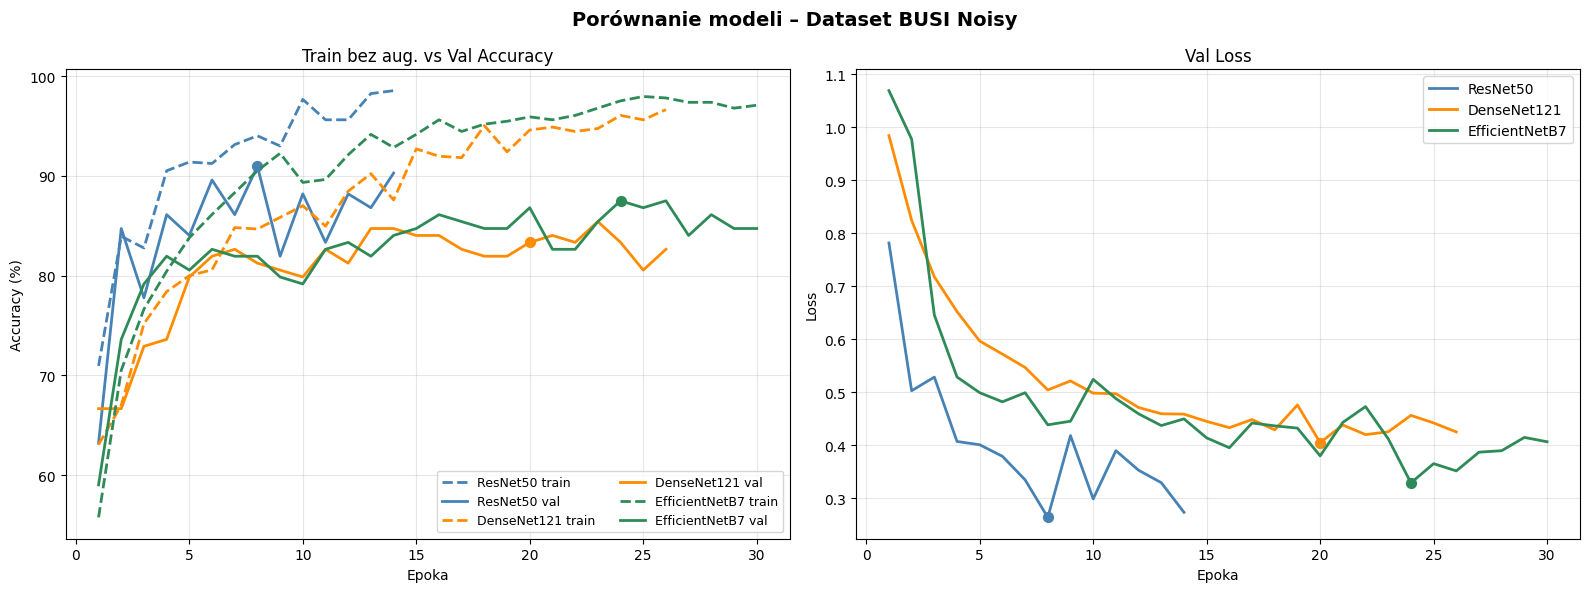

Wykres zapisany: classification_comparison.png


In [16]:
import matplotlib.pyplot as plt

# --- Tabela podsumowująca ---
summary = pd.DataFrame({
    'Model': ['ResNet50', 'DenseNet121', 'EfficientNetB7'],
    'Test Accuracy (%)': [
        round(resnet_test_acc * 100, 2),
        round(densenet_test_acc * 100, 2),
        round(eff_test_acc * 100, 2),
    ],
    'Test Loss': [
        round(resnet_test_loss, 4),
        round(densenet_test_loss, 4),
        round(eff_test_loss, 4),
    ],
    'Best Train Accuracy (%) - bez aug.': [
        round(resnet_stats['best_train_eval_accuracy'] * 100, 2),
        round(densenet_stats['best_train_eval_accuracy'] * 100, 2),
        round(eff_stats['best_train_eval_accuracy'] * 100, 2),
    ],
    'Best Val Accuracy (%)': [
        round(resnet_stats['best_val_accuracy'] * 100, 2),
        round(densenet_stats['best_val_accuracy'] * 100, 2),
        round(eff_stats['best_val_accuracy'] * 100, 2),
    ],
    'Best Epoch': [
        resnet_stats['best_epoch'],
        densenet_stats['best_epoch'],
        eff_stats['best_epoch'],
    ],
    'Liczba epok': [
        resnet_stats['epochs_ran'],
        densenet_stats['epochs_ran'],
        eff_stats['epochs_ran'],
    ],
    'Czas treningu (s)': [
        round(resnet_train_time, 1),
        round(densenet_train_time, 1),
        round(eff_train_time, 1),
    ],
})

print('\n' + '=' * 75)
print('PODSUMOWANIE KLASYFIKACJI – BUSI NOISY DATASET')
print('=' * 75)
print(summary.to_string(index=False))

best_model = summary.loc[summary['Test Accuracy (%)'].idxmax(), 'Model']
print(f"\nNajlepszy model: {best_model} ({summary['Test Accuracy (%)'].max():.2f}% na zbiorze testowym)")

# Zapis zbiorczego CSV
summary_csv = os.path.join(results_dir, 'classification_summary.csv')
summary.to_csv(summary_csv, index=False)
print(f"Podsumowanie zapisane: {summary_csv}")

# --- Wykresy (każdy model ma własną oś X = faktyczna liczba epok) ---
histories = {
    'ResNet50': (resnet_history, resnet_stats),
    'DenseNet121': (densenet_history, densenet_stats),
    'EfficientNetB7': (eff_history, eff_stats),
}
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Porównanie modeli – Dataset BUSI Noisy', fontsize=14, fontweight='bold')

for (name, (history, stats)), color in zip(histories.items(), colors):
    x = range(1, stats['epochs_ran'] + 1)
    best_idx = stats['best_epoch'] - 1
    axes[0].plot(x, [value * 100 for value in history['train_eval_accuracy']], label=f'{name} train', color=color, linewidth=2, linestyle='--')
    axes[0].plot(x, [value * 100 for value in history['val_accuracy']], label=f'{name} val', color=color, linewidth=2)
    axes[1].plot(x, history['val_loss'], label=name, color=color, linewidth=2)
    axes[0].scatter(stats['best_epoch'], history['val_accuracy'][best_idx] * 100, color=color, s=50)
    axes[1].scatter(stats['best_epoch'], history['val_loss'][best_idx], color=color, s=50)

axes[0].set_title('Train bez aug. vs Val Accuracy')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(ncol=2, fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title('Val Loss')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'classification_comparison.png'), dpi=150)
plt.show()
print('Wykres zapisany: classification_comparison.png')